Mini-Project: Binary Text Classification with IMDB Dataset (CNN) - 11 JUILLET 2025

🧩 Étape 1 : Prétraitement des données
🔹 Objectif :
Charger le jeu de données IMDB, transformer les séquences d'entiers en vecteurs binaires utilisables par un réseau de neurones.

🔸 1.1 Chargement des données
Le jeu de données IMDB est directement accessible via keras.datasets. Chaque critique est déjà prétraitée et représentée comme une liste d'entiers correspondant aux mots les plus fréquents.

from keras.datasets import imdb

# On ne garde que les 10 000 mots les plus fréquents
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)
x_train et x_test : listes de critiques (chaque critique = séquence d’indices entiers).

y_train et y_test : étiquettes associées (0 = négatif, 1 = positif).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# 1. Preprocess the Data:
# 1.1 Chargement des données
    # Objectif : Charger le jeu de données IMDB, transformer les séquences d'entiers en vecteurs binaires utilisables par un réseau de neurones.
    # Chargement des données Le jeu de données IMDB est directement accessible via keras.datasets.
    # Chaque critique est déjà prétraitée et représentée comme une liste d'entiers correspondant aux mots les plus fréquents.

from keras.datasets import imdb
imdb.load_data()

    # On limite le vocabulaire aux 10 000 mots les plus fréquents
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

    # Commentaires :
        # train_data et test_data : des listes d'entiers représentant les critiques.
        # train_labels et test_labels : 0 = critique négative, 1 = critique positive.
        # num_words=10000 : on ne garde que les 10 000 mots les plus fréquents dans les critiques.

In [ ]:
    # Comprendre le format des données
print(train_data[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [ ]:
print(train_labels[0])

1


Commentaire : Les critiques sont des séquences de longueurs différentes, ce qui n’est pas compatible directement avec un réseau dense.

In [ ]:
# 1.2 Convert the sequences of integers into binary matrices using one-hot encoding.
    # Utilisons la fonction de vectorisation proposée :

import numpy as np

    # COMMENTAIRES : Pourquoi on doit vectoriser les données?
      # Les critiques sont actuellement des listes d’entiers (ex. [1, 14, 22, 16, 43, 530, ...]), et chaque entier représente un mot.
      # Problème : Un réseau de neurones ne peut pas traiter des listes d’entiers de longueur variable.
      # Solution : Transformer chaque critique en vecteur binaire (one-hot encoding) de taille 10 000 avec des 1 aux indices correspondant aux mots présents.
      # La fonction vectorize_sequences() crée une matrice de zéros, puis remplit chaque ligne avec des 1 aux indices des mots présents.

import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Matrice remplie de zéros, taille (nombre_de_critiques, 10000)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0  # met 1.0 aux indices correspondant aux mots présents
    return results

# Vectorisation des données d'entraînement et de test
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# x_train et x_test sont à présent des matrices de dimension (nb_échantillons, 10000), prêtes à être utilisées par un modèle dense.
# Chaque ligne de x_train est une critique, transformée en vecteur. Le modèle pourra maintenant traiter ces vecteurs dans une couche Dense.

In [ ]:
# Conversion des labels en float :
  # Les étiquettes sont déjà des entiers 0 ou 1, mais on les convertit en float32 pour qu’elles soient compatibles avec le modèle :

import numpy as np

# Charger les 50 000 critiques (train + test) avec les 10 000 mots les plus fréquents
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

In [ ]:
# 1.3 Split the data into training, validation, and test sets.
    # Séparer un ensemble de validation - pour surveiller les performances pendant l'entraînement, on réserve 10 000 critiques pour la validation (On sépare une portion de x_train pour créer un jeu de validation) :

x_val = x_train[:10000]           # 10 000 premières critiques pour validation
partial_x_train = x_train[10000:] # Le reste pour l'entraînement

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

    # Commentaire : nous avons vectorisé nos critiques (entrées) en vecteurs de 10 000 dimensions (des 0 et 1), et nos étiquettes sont des 0 (négatif) ou 1 (positif). Il s'agit donc d'un problème de classification binaire.

In [ ]:
# 2. Construction du modèle
    # Objectif : créer un réseau de neurones simple (aussi appelé feedforward) entièrement connecté pour classer les critiques en positif (1) ou négatif (0).

    # 2.1 Architecture du modèle :
      # Choix d'un modèle séquentiel (réseau de neurones feedforward) avec:
          # Données d'entrée : vecteurs de 10 000 dimensions (one-hot encoding), associé des étiquettes sous forme de scalaires (des 1 et des 0)
          # Deux couches connectées cachées (Dense)  de 16 neurones avec activation ReLU.
          # Sortie : une seule unité avec sigmoïde pour produire une probabilité (entre 0 et 1).
          # Compilation du modèle avec :
              # optimiseur RMSprop,
              # perte binary_crossentropy,
              # et métrique d’évaluation accuracy.

      # 2.1.1. Importation des modules nécessaires
from tensorflow.keras import models
from tensorflow.keras import layers

      # 2.1.2. Définition du modèle : séquentiel (empilement linéaire de couches)
model = models.Sequential()

# Choix d'un modèle Sequential (c’est-à-dire une empilement linéaire de couches.) : ici, on empile les couches dans un ordre simple (entrée → cachées → sortie), sans branchement ou connexions complexes.

In [ ]:
    # 2.2 - Ajout des couches cachées
      # Première couche Dense : 8 neurones (ou unités), activation ReLU, avec une entrée de 10 000 dimensions
model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))

      # Deuxième couche Dense identique
model.add(layers.Dense(8, activation='relu'))

# Commentaires :
    # Dense(8) pour 8 neurones par couche, chacune connecté à toutes les entrées de la couche précédente.
    # input_shape=(10000,) indique que chaque donnée d’entrée est un vecteur de 10 000 mots encodés (présence/absence).

In [ ]:
    # 2.3 - Ajout de la couche de sortie
      # Couche de sortie : 1 neurone avec une activation sigmoïde
model.add(layers.Dense(1, activation='sigmoid'))
# Commentaires : Choix d'une fonction Sigmoid, parce qu’on veut prédire une probabilité (si la sortie est proche de 1 → critique positive; Si proche de 0 → critique négative)

In [ ]:
    # 2.4 - Compilation du modèle
        # Le modèle doit être "compilé" pour que Keras sache :
        # comment s'entraîner (optimiseur)
        # comment calculer l'erreur (fonction de perte)
        # quelle métrique afficher

model.compile(
    optimizer='rmsprop',             # Optimiseur RMSprop (bon choix pour les petits réseaux et stable pour des jeux de données comme IMDB)
    loss='binary_crossentropy',      # Fonction de perte pour classification binaire (mesure la différence entre la sortie du modèle et le label 0 ou 1)
    metrics=['accuracy']             # Suivi de la précision pendant l’entraînement (mesure la proportion de prédictions correctes)
)
# Commentaires :
  # RMSprop : très bien adapté pour ce type de tâche, car ajuste automatiquement le taux d’apprentissage selon l’historique des gradients.
  # binary_crossentropy : compare la sortie sigmoïde à la vérité terrain (0 ou 1), pénalise fortement les mauvaises prédictions.
  # accuracy : pourcentage de prédictions correctes.

In [ ]:
model.summary()   # Pour résumer.

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,402 (626.57 KB)

 Trainable params: 160,402 (626.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("partial_x_train shape :", partial_x_train.shape)
print("partial_y_train shape :", partial_y_train.shape)
print("x_val shape           :", x_val.shape)
print("y_val shape           :", y_val.shape)

partial_x_train shape : (15000, 10000)
partial_y_train shape : (15000,)
x_val shape           : (10000, 10000)
y_val shape           : (10000,)


In [ ]:
# 3. Entraînement du modèle (Train the Model):
    # Objectif : Entraîner le modèle sur les données d’apprentissage pendant 20 époques avec une taille de batch de 512, tout en utilisant un jeu de validation pour surveiller la performance.

    # 3.1 Préparation des données (ces jeux doivent être prétraités, avec textes encodés en vecteurs de taille 10 000, et normalisés si besoin) :
      # x_train : données d’entraînement
      # y_train : labels d’entraînement
      # x_val : données de validation
      # y_val : labels de validation

    # Hypothèse : x_train_full et y_train_full sont déjà préparés
      # Séparation en jeu d'entraînement (40 000) et validation (10 000)

from keras.datasets import imdb
import numpy as np

# 1) Charger les données
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# 2) Vectoriser en one-hot
def vectorize_sequences(sequences, dim=10000):
    results = np.zeros((len(sequences), dim), dtype="float32")
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train = vectorize_sequences(x_train)
x_test  = vectorize_sequences(x_test)
y_train = np.asarray(y_train).astype("float32")
y_test  = np.asarray(y_test).astype("float32")

# 3) Split train/val — attention aux longueurs
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# 4) Re-créer le modèle compatible (input_shape=10000)
from keras import models, layers
model = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# 5) Entraînement
history = model.fit(
    partial_x_train, partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6897 - loss: 0.6083 - val_accuracy: 0.8682 - val_loss: 0.3969
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8935 - loss: 0.3417 - val_accuracy: 0.8837 - val_loss: 0.3146
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9255 - loss: 0.2393 - val_accuracy: 0.8896 - val_loss: 0.2865
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9373 - loss: 0.1940 - val_accuracy: 0.8821 - val_loss: 0.2911
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9494 - loss: 0.1615 - val_accuracy: 0.8844 - val_loss: 0.2939
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9602 - loss: 0.1341 - val_accuracy: 0.8867 - val_loss: 0.2841
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9668 - loss: 0.1135 - val_accuracy: 0.8802 - val_loss: 0.3051
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9750 - loss: 0.0939 - val_accuracy: 0.8729 - v

In [ ]:
# 4. Evaluate the Model, étape par étape, avec des explications très détaillées.
 # Objectif :
    # Visualiser les pertes et précisions pour détecter un éventuel surapprentissage (overfitting).
    # Déterminer le bon nombre d’époques pour réentraîner le modèle.
    # Évaluer la performance finale sur les données de test.

    # 4.1 Récupérer les données d’apprentissage
        # L’objet history renvoyé par model.fit() contient les métriques d'entraînement et de validation pour chaque époque.

history_dict = history.history        # Cela te donne un dictionnaire comme :
{
  'loss': [...],
  'val_loss': [...],
  'accuracy': [...],
  'val_accuracy': [...]
}


{'loss': [Ellipsis],
 'val_loss': [Ellipsis],
 'accuracy': [Ellipsis],
 'val_accuracy': [Ellipsis]}

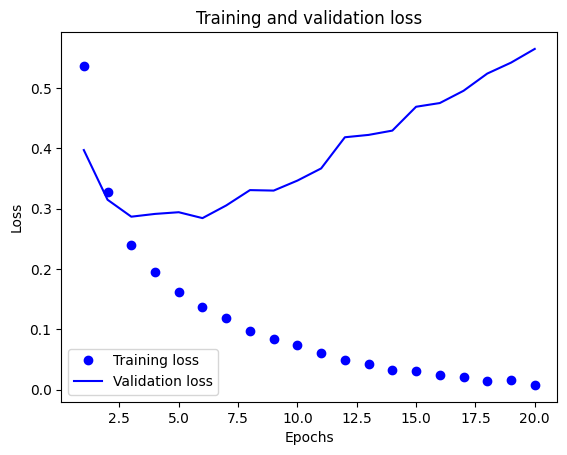

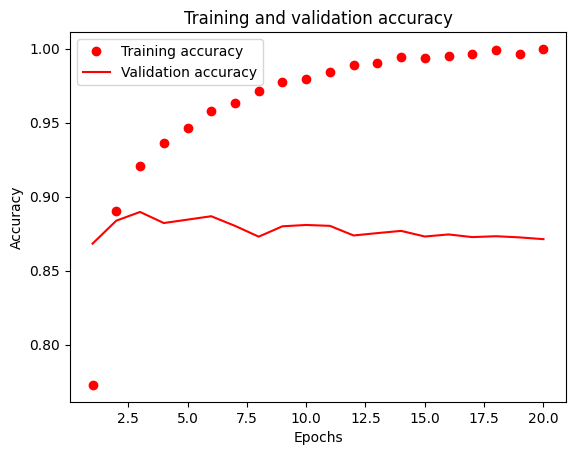

In [ ]:
    # Étape 4.2 : Tracer les courbes (loss et accuracy) - on utilise matplotlib pour visualiser ces données.

import matplotlib.pyplot as plt

# Extraire les données
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

# Courbe des pertes
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Courbe des précisions
plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 5. Analyze Results, en expliquant chaque étape comme pour un débutant.

 # Objectif :
    # Comparer les métriques (perte et précision) sur l’entraînement et la validation, pour évaluer le comportement du modèle (sous-apprentissage, sur-apprentissage, etc.).
    # Rapporter la performance finale (perte et précision) sur le jeu de test, c’est-à-dire sur des données jamais vues jusqu’ici.

    # 5.1 Visualiser les courbes entraînement/validation
        # On commence par extraire les valeurs de perte et précision enregistrées dans l’objet history.
    # 5.2 Interprétation :
        # Voici ce que je recherche dans les courbes :
            # Perte validation qui augmente alors que celle d'entraînement diminue → sur-apprentissage.
            # Précision validation qui stagne ou chute alors que celle d'entraînement continue à monter → modèle trop spécialisé sur l'entraînement.
            # Les deux courbes sont proches et montent ensemble → bon apprentissage général.

        # Graphique des pertes (loss)
            # La perte d’entraînement diminue régulièrement jusqu’à devenir très faible → le modèle apprend bien à prédire les données d'entraînement.
            # La perte de validation, quant à elle diminue au début (jusqu’à l’époque ~4-5), puis commence à remonter, de manière irrégulière mais claire.
            # Conclusion : c’est un cas de sur-apprentissage (overfitting). À partir de l’époque 5 ou 6, le modèle mémorise les données d'entraînement au lieu de généraliser.
        # Graphique des précisions (accuracy)
            # La précision d’entraînement monte de façon continue jusqu’à quasiment 100 %.
            # La précision de validation augmente jusqu’à l’époque ~4-5, puis stagne ou baisse légèrement.
            # Le modèle s’améliore sur l’entraînement, mais perd en capacité de généralisation après la 5e époque.

        # CONCLUSION : ce modèle est trop entraîné (données d’apprentissage) → il a appris à “trop bien” prédire ces données mais échoue à généraliser sur des données inconnues.

    # 5.3 Évaluer sur les données de test - le test final se fait sur un jeu de données jamais utilisé jusque-là (ni pour entraînement, ni pour validation).
results = model.evaluate(x_test, y_test)
print(f"Perte sur test : {results[0]:.4f}")
print(f"Précision sur test : {results[1]*100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8565 - loss: 0.5768
Perte sur test : 0.5616
Précision sur test : 86.18%


In [ ]:
    # 5.4 Pistes d'amélioration concrètes
        # 5.4.1 Réduire le nombre d’époques => s'arrêter à 4 ou 5 époques aurait permis de préserver les meilleures performances de validation.
            # Correction proposée : utiliser EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9991 - loss: 0.0139 - val_accuracy: 0.8690 - val_loss: 0.5497
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9994 - loss: 0.0115 - val_accuracy: 0.8696 - val_loss: 0.5744
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9998 - loss: 0.0087 - val_accuracy: 0.8675 - val_loss: 0.5962
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9984 - loss: 0.0142 - val_accuracy: 0.8683 - val_loss: 0.5743
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9995 - loss: 0.0084 - val_accuracy: 0.8677 - val_loss: 0.5970
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9992 - loss: 0.0089 - val_accuracy: 0.8676 - val_loss: 0.6227


In [ ]:
        # 5.4.2. Réduire la complexité du modèle
            # 2 couches cachées de 16 neurones peuvent suffire, mais possible aussi d'essayer moins de neurones (ex. 8), ou une seule couche cachée.

        # 5.4.3. Ajouter du dropout
            # Le dropout coupe aléatoirement des connexions pendant l’entraînement, ce qui évite la sur-mémorisation.

from keras import models, layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dropout(0.5))  # 50% de neurones ignorés temporairement
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
        # 5.4.4. Régularisation L2 (qui pénalise les poids trop élevés) :
from keras import regularizers

model.add(layers.Dense(16, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001)))

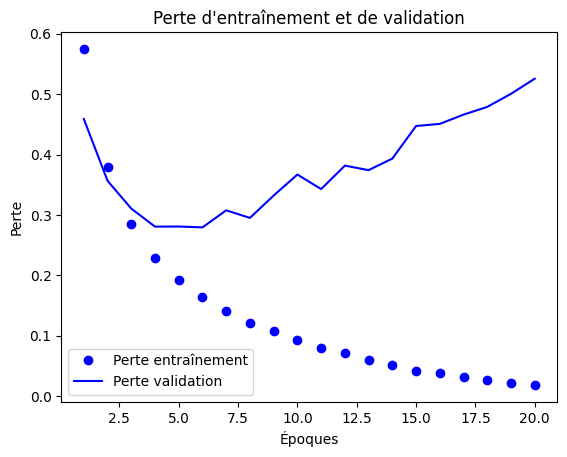

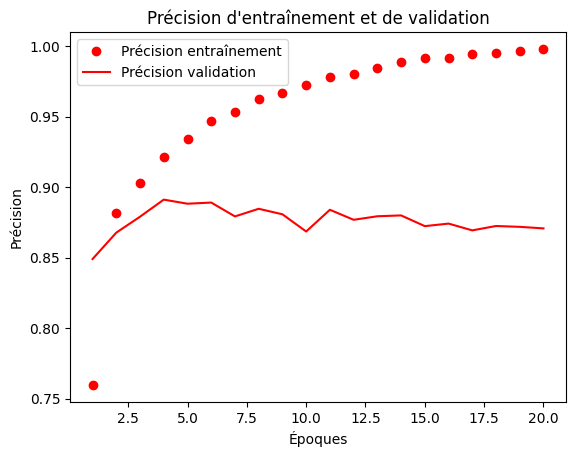

In [ ]:
import matplotlib.pyplot as plt

# Récupérer les métriques
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

# Générer la liste des époques
epochs = range(1, len(loss) + 1)

# Tracer la courbe de la perte
plt.plot(epochs, loss, 'bo', label='Perte entraînement')        # 'bo' = blue dot
plt.plot(epochs, val_loss, 'b', label='Perte validation')       # 'b' = ligne bleue
plt.title("Perte d'entraînement et de validation")
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()
plt.show()

# Tracer la courbe de la précision
plt.plot(epochs, accuracy, 'ro', label='Précision entraînement')   # rouge point
plt.plot(epochs, val_accuracy, 'r', label='Précision validation')  # rouge ligne
plt.title("Précision d'entraînement et de validation")
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.show()
